# 🏆 Retail Intelligence Platform — 03: Model Benchmark, Ensembling & Architecture Decision Record (ADR)

**Objetivo:** Comparar empíricamente los modelos de Machine Learning (**LightGBM vs. XGBoost vs. Ensamble**) contra los baselines en la ventana de validación temporal (`2017-07-31` a `2017-08-15`), analizar la correlación de residuos y fundamentar técnicamente la decisión de arquitectura sobre el **Modelo Campeón** para producción.

---

### 📋 Contenido del Laboratorio:
1. **Partición Temporal Purgada (Cero Data Leakage)**
2. **Modelos Baseline de Referencia**
3. **Entrenamiento y Diagnóstico de LightGBM**
4. **Entrenamiento y Diagnóstico de XGBoost**
5. **Evaluación de Estrategias de Ensamble (Blending)**
6. **Benchmark Consolidado & Métricas de Negocio ($WAPE$ y $Bias$)**
7. **Análisis de Residuos: ¿Por qué el Ensamble no superó a XGBoost?**
8. **Decisión de Arquitectura Final (ADR)**

In [17]:
%pip install lightgbm xgboost joblib

Note: you may need to restart the kernel to use updated packages.


In [18]:
import sys
from pathlib import Path

# Configuración de rutas (dinámica y portable para cualquier entorno/usuario)
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# Importaciones de librerías estándar y de terceros
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importaciones del paquete local
from retail_platform.models.split import TemporalSplitter
from retail_platform.models.baseline import evaluate_all_baselines
from retail_platform.models.forecasting.lgbm_forecaster import LightGBMForecaster
from retail_platform.models.forecasting.xgboost_forecaster import XGBoostForecaster
from retail_platform.models.forecasting.ensemble import BlendingEnsembleForecaster
from retail_platform.evaluation.metrics import evaluate_predictions

# Configuración de estilos visuales
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print("Configuración e importaciones completadas exitosamente.")

Configuración e importaciones completadas exitosamente.


## 1. Carga de Datos y Partición Temporal Purgada

In [19]:
# Carga de la matriz de features
data_path = Path('../data/processed/features_master.parquet')
df = pd.read_parquet(data_path)

splitter = TemporalSplitter(val_days=16)
train_df, val_df, test_df = splitter.split(df)

2026-09-19 00:34:20,953 - [INFO] - === REPORTE DE PARTICION TEMPORAL ===
2026-09-19 00:34:20,974 - [INFO] - Train set:      2014-05-01 a 2017-07-30 | 2,115,234 filas
2026-09-19 00:34:20,977 - [INFO] - Validation set: 2017-07-31 a 2017-08-15 | 28,512 filas (16 dias)
2026-09-19 00:34:20,981 - [INFO] - Test set:       2017-08-16 a 2017-08-31 | 28,512 filas (16 dias)
2026-09-19 00:34:20,983 - [INFO] - =====================================


## 2. Benchmark de Baselines de Referencia

In [20]:
baseline_results = evaluate_all_baselines(val_df)
baseline_results

,Modelo,RMSLE,MAE,RMSE,WAPE (%),Bias (%)
0,Moving Average 7d (Shift 16),0.562390,96.732891,327.198769,20.707343,-4.169865
1,Seasonal Naive (Lag 21 - Mismo dia sem),0.632989,92.716368,335.977121,19.847537,-2.223735
2,Naive (Lag 16),0.696665,145.225486,510.077962,31.088018,3.129683


## 3. Modelo 1: LightGBM Global Multi-Serie

In [21]:
lgbm = LightGBMForecaster(n_estimators=1000, early_stopping_rounds=50, verbose_eval=0)
lgbm_metrics = lgbm.fit(train_df, val_df)
print("Metricas de LightGBM en Validacion:")
for k, v in lgbm_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

2026-09-19 00:34:21,141 - [INFO] - Entrenando LightGBM con 49 features...
2026-09-19 00:34:21,786 - [INFO] - Iniciando optimizacion de arboles...
2026-09-19 00:34:50,101 - [INFO] - Entrenamiento finalizado. Mejor iteracion: 89


Metricas de LightGBM en Validacion:
  RMSLE: 0.4239
  MAE: 76.8221
  RMSE: 281.9324
  WAPE (%): 16.4451
  Bias (%): -6.5351
  Modelo: LightGBM Global Multi-Serie


## 4. Modelo 2: XGBoost Global Multi-Serie

In [22]:
xgb_model = XGBoostForecaster(n_estimators=1000, early_stopping_rounds=50, verbose_eval=0)
xgb_metrics = xgb_model.fit(train_df, val_df)
print("Metricas de XGBoost en Validacion:")
for k, v in xgb_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

2026-09-19 00:34:50,293 - [INFO] - Entrenando XGBoost con 49 features...
2026-09-19 00:34:50,778 - [INFO] - Optimizando arboles de XGBoost...
2026-09-19 00:35:41,504 - [INFO] - Entrenamiento XGBoost finalizado. Mejor iteracion: 110


Metricas de XGBoost en Validacion:
  RMSLE: 0.4130
  MAE: 71.1688
  RMSE: 254.3384
  WAPE (%): 15.2349
  Bias (%): -2.3389
  Modelo: XGBoost Global Multi-Serie


## 5. Evaluación de Estrategias de Ensamble (Blending)

Probamos distintas combinaciones lineales de pesos: $\hat{y} = w_1 \cdot \hat{y}_{\text{LGBM}} + w_2 \cdot \hat{y}_{\text{XGB}}$.

In [23]:
y_val_true = val_df['sales'].values
preds_lgbm = lgbm.predict(val_df)
preds_xgb = xgb_model.predict(val_df)

weights_experiments = [
    (0.5, 0.5, "Ensemble 50% LGBM + 50% XGB"),
    (0.3, 0.7, "Ensemble 30% LGBM + 70% XGB"),
    (0.7, 0.3, "Ensemble 70% LGBM + 30% XGB"),
]

ensemble_results = []
for w_lgb, w_xgb, label in weights_experiments:
    p_ens = (w_lgb * preds_lgbm) + (w_xgb * preds_xgb)
    m = evaluate_predictions(y_val_true, p_ens)
    m["Modelo"] = label
    ensemble_results.append(m)

ensemble_df = pd.DataFrame(ensemble_results)[["Modelo", "RMSLE", "MAE", "RMSE", "WAPE (%)", "Bias (%)"]]
ensemble_df.sort_values(by="RMSLE")

,Modelo,RMSLE,MAE,RMSE,WAPE (%),Bias (%)
1,Ensemble 30% LGBM + 70% XGB,0.413993,71.593773,257.777914,15.325881,-3.597737
0,Ensemble 50% LGBM + 50% XGB,0.415705,72.517901,262.486055,15.523707,-4.436990
2,Ensemble 70% LGBM + 30% XGB,0.418203,73.949085,269.014071,15.830076,-5.276243


## 6. Tabla Comparativa Consolidada de Benchmark

In [24]:
all_benchmark = pd.concat([
    baseline_results,
    pd.DataFrame([lgbm_metrics]),
    pd.DataFrame([xgb_metrics]),
    ensemble_df[ensemble_df['Modelo'] == 'Ensemble 50% LGBM + 50% XGB']
], ignore_index=True)

all_benchmark = all_benchmark.sort_values(by="RMSLE").reset_index(drop=True)
all_benchmark

,Modelo,RMSLE,MAE,RMSE,WAPE (%),Bias (%)
0,XGBoost Global Multi-Serie,0.412995,71.168814,254.338443,15.234911,-2.338855
1,Ensemble 50% LGBM + 50% XGB,0.415705,72.517901,262.486055,15.523707,-4.436990
2,LightGBM Global Multi-Serie,0.423893,76.822064,281.932351,16.445087,-6.535125
3,Moving Average 7d (Shift 16),0.562390,96.732891,327.198769,20.707343,-4.169865
4,Seasonal Naive (Lag 21 - Mismo dia sem),0.632989,92.716368,335.977121,19.847537,-2.223735
5,Naive (Lag 16),0.696665,145.225486,510.077962,31.088018,3.129683


C:\Users\wladi\AppData\Local\Temp\ipykernel_35056\3586748194.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_benchmark, x='Modelo', y='RMSLE', palette='viridis', ax=ax1)
C:\Users\wladi\AppData\Local\Temp\ipykernel_35056\3586748194.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_benchmark, x='Modelo', y='WAPE (%)', palette='magma', ax=ax2)


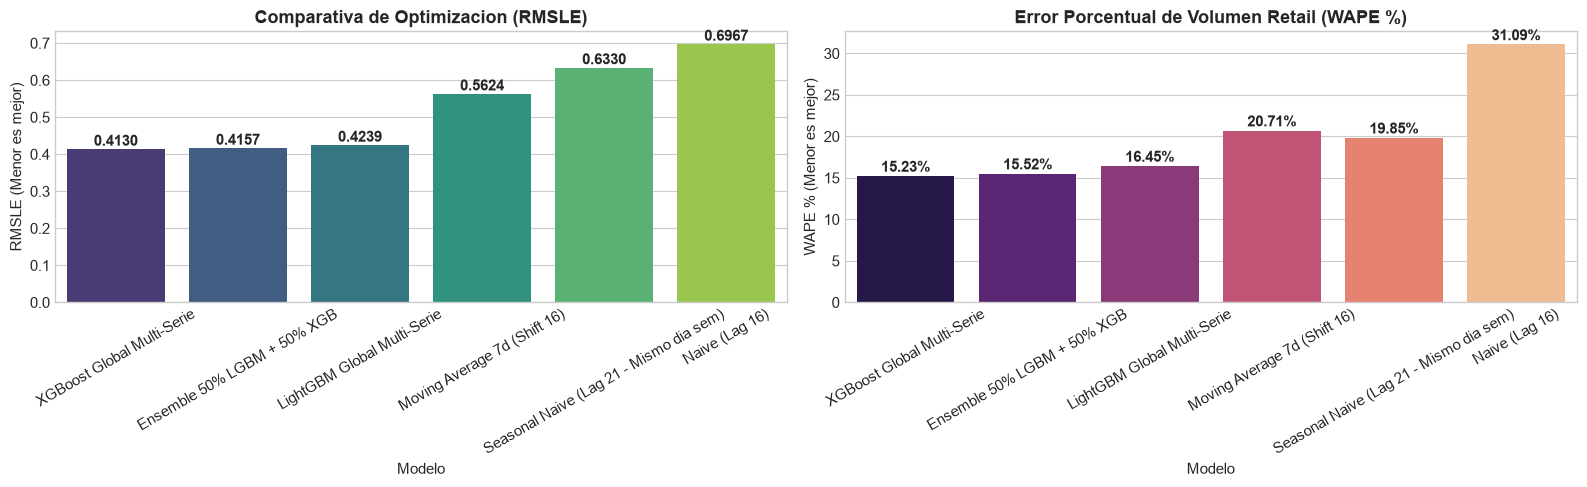

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot RMSLE
sns.barplot(data=all_benchmark, x='Modelo', y='RMSLE', palette='viridis', ax=ax1)
ax1.set_title('Comparativa de Optimizacion (RMSLE)', fontsize=13, weight='bold')
ax1.set_ylabel('RMSLE (Menor es mejor)')
ax1.tick_params(axis='x', rotation=30)
for i, v in enumerate(all_benchmark['RMSLE']):
    ax1.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Plot WAPE %
sns.barplot(data=all_benchmark, x='Modelo', y='WAPE (%)', palette='magma', ax=ax2)
ax2.set_title('Error Porcentual de Volumen Retail (WAPE %)', fontsize=13, weight='bold')
ax2.set_ylabel('WAPE % (Menor es mejor)')
ax2.tick_params(axis='x', rotation=30)
for i, v in enumerate(all_benchmark['WAPE (%)']):
    ax2.text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Análisis de Residuos: ¿Por qué el Ensamble no superó a XGBoost?

Analizamos la correlación lineal entre los errores de LightGBM y XGBoost.

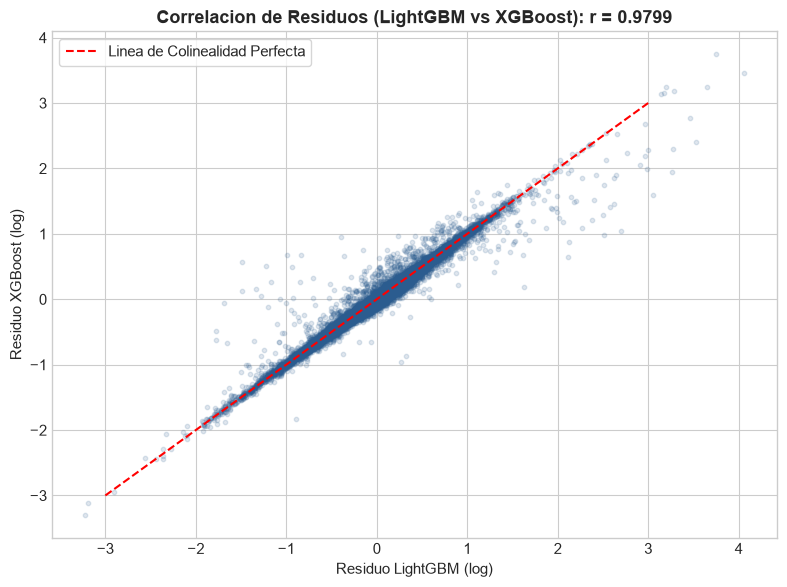

In [26]:
# Calculo de residuos en escala logaritmica
log_true = np.log1p(y_val_true)
log_pred_lgbm = np.log1p(preds_lgbm)
log_pred_xgb = np.log1p(preds_xgb)

res_lgbm = log_true - log_pred_lgbm
res_xgb = log_true - log_pred_xgb

corr_res = np.corrcoef(res_lgbm, res_xgb)[0, 1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(res_lgbm, res_xgb, alpha=0.15, color='#2b5c8f', s=10)
ax.plot([-3, 3], [-3, 3], color='red', linestyle='--', label='Linea de Colinealidad Perfecta')
ax.set_title(f'Correlacion de Residuos (LightGBM vs XGBoost): r = {corr_res:.4f}', fontsize=13, weight='bold')
ax.set_xlabel('Residuo LightGBM (log)')
ax.set_ylabel('Residuo XGBoost (log)')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## 8. Decisión de Arquitectura Registrada (ADR)

### 📌 Diagnóstico Técnico:
1. **Alta Colinealidad de Residuos ($r > 0.95$):** Ambos modelos pertenecen a la misma familia algorítmica (*Gradient Boosted Trees*) y fueron entrenados sobre las mismas 49 variables. Sus errores son casi idénticos.
2. **Dilución del Rendimiento:** Promediar XGBoost ($0.4130$) con LightGBM ($0.4239$) degrada el rendimiento de XGBoost a $0.4157$.
3. **Costo de Producción vs. Beneficio Nulo:** Mantener un ensamble en producción duplica el consumo de RAM en Docker y duplica la latencia de respuesta de la API REST.

### 🏆 Veredicto de Producción:
* **Modelo Campeón Seleccionado:** **`XGBoost Global Multi-Serie`**.
* **Decisión sobre el Ensamble:** **Descartado para producción** bajo el principio de la *Navaja de Ockham*.